**1. Import des librairies**

In [35]:


import pandas as pd
import os
import glob

**2. Définir le chemin du dataset**

In [2]:
DATA_DIR = "/kaggle/input/datasets/sarafarjallah/blackblaze/"

**3. Fonction pour charger un dossier**

In [3]:
import pandas as pd
import glob
import warnings
warnings.filterwarnings("ignore")

DATA_DIR = "/kaggle/input/datasets/sarafarjallah/blackblaze/"
TARGET_MODEL = "ST4000DM000"

TRAIN_FOLDERS = [
    DATA_DIR + "data_Q1_2017/",
    DATA_DIR + "data_Q2_2017/",
    DATA_DIR + "data_Q3_2017/",
    DATA_DIR + "data_Q4_2017/",
]
TEST_FOLDER = DATA_DIR + "data_Q4_2016/"
def charger_dossier(dossier):
    fichiers = sorted(glob.glob(dossier + "*.csv"))
    dfs = []
    for f in fichiers:
        for chunk in pd.read_csv(f, low_memory=False, chunksize=5000):
            chunk = chunk[chunk["model"] == TARGET_MODEL]
            if not chunk.empty:
                dfs.append(chunk)
    return pd.concat(dfs, ignore_index=True)
df_train = pd.concat([charger_dossier(f) for f in TRAIN_FOLDERS], ignore_index=True)
df_test  = charger_dossier(TEST_FOLDER)
for nom, df in [("TRAIN", df_train), ("TEST", df_test)]:
    print(f"\n===== {nom} =====")
    print("Dimensions :", df.shape)
    print("Types :\n", df.dtypes)
    print("Premières lignes :\n", df.head())


===== TRAIN =====
Dimensions : (12237899, 95)
Types :
 date                     object
serial_number            object
model                    object
capacity_bytes            int64
failure                   int64
                         ...   
smart_252_raw           float64
smart_254_normalized    float64
smart_254_raw           float64
smart_255_normalized    float64
smart_255_raw           float64
Length: 95, dtype: object
Premières lignes :
          date serial_number        model  capacity_bytes  failure  \
0  2017-01-01      Z305B2QN  ST4000DM000   4000787030016        0   
1  2017-01-01      Z302A0YH  ST4000DM000   4000787030016        0   
2  2017-01-01      Z305BT0W  ST4000DM000   4000787030016        0   
3  2017-01-01      Z302A0YE  ST4000DM000   4000787030016        0   
4  2017-01-01      Z302PGH8  ST4000DM000   4000787030016        0   

   smart_1_normalized  smart_1_raw  smart_2_normalized  smart_2_raw  \
0               113.0   58173272.0                 NaN      

**2.2 Détection et suppression des colonnes constantes**

In [4]:


def detect_constant_columns(df, keyword="smart_"):
    constant_cols    = []
    informative_cols = []

    for col in [c for c in df.columns if keyword in c]:
        serie = df[col].dropna()
        if serie.empty or serie.nunique() <= 1 or serie.min() == serie.max():
            constant_cols.append(col)
        else:
            informative_cols.append(col)

    return constant_cols, informative_cols
constant_cols, informative_cols = detect_constant_columns(df_train)
cols_avant = df_train.shape[1]
print("Dimensions AVANT :", df_train.shape)
for col in constant_cols[:5]:
    print(col, "→ valeurs uniques :", df_train[col].dropna().unique())

df_train = df_train.drop(columns=constant_cols)
df_test  = df_test.drop(columns=constant_cols, errors="ignore")
cols_apres     = df_train.shape[1]
nb_smart_total = len(constant_cols) + len(informative_cols)

print("Dimensions APRÈS :", df_train.shape)
print(f"Colonnes supprimées : {len(constant_cols)} / Restantes : {len(informative_cols)}")
print(f"Réduction SMART : {round(len(constant_cols)/nb_smart_total*100, 1)}%")
print(f"Réduction TOTAL : {round((cols_avant - cols_apres)/cols_avant*100, 1)}%")

Dimensions AVANT : (12237899, 95)
smart_2_normalized → valeurs uniques : []
smart_2_raw → valeurs uniques : []
smart_3_raw → valeurs uniques : [0.]
smart_8_normalized → valeurs uniques : []
smart_8_raw → valeurs uniques : []
Dimensions APRÈS : (12237899, 44)
Colonnes supprimées : 51 / Restantes : 39
Réduction SMART : 56.7%
Réduction TOTAL : 53.7%


**2.3 Nettoyage et sélection finale des données**

In [5]:

# 1. Supprimer colonnes entièrement vides
df_train = df_train.dropna(axis=1, how='all')
df_test  = df_test.dropna(axis=1, how='all')

# 2. Supprimer lignes avec valeurs manquantes critiques
df_train = df_train.dropna(subset=['date', 'serial_number', 'failure'])
df_test  = df_test.dropna(subset=['date', 'serial_number', 'failure'])

# 3. Remplacer les valeurs manquantes restantes par 0
df_train = df_train.fillna(0)
df_test  = df_test.fillna(0)

# 4. Sélectionner les colonnes finales (métadonnées + SMART raw)
meta_cols  = ['date', 'serial_number', 'failure']
smart_cols = [c for c in df_train.columns if 'smart_' in c and '_raw' in c]
final_cols = meta_cols + smart_cols

df_train = df_train[final_cols]
df_test  = df_test[final_cols]

# 5. Vérifier que train et test ont les mêmes colonnes
assert list(df_train.columns) == list(df_test.columns), "Colonnes différentes!"

# Résultat
print("Train shape :", df_train.shape)
print("Test shape  :", df_test.shape)
print("NaN train   :", df_train.isna().sum().sum())
print("NaN test    :", df_test.isna().sum().sum())

Train shape : (12237899, 24)
Test shape  : (3196552, 24)
NaN train   : 0
NaN test    : 0


**2.4 Sauvegarde des données préparées**

In [6]:
import time
import os
import glob
import pandas as pd

save_dir       = "/kaggle/working/"
pkl_train_file = "train_2017.pkl"
pkl_test_file  = "test_2016_Q4.pkl"

# 1. Sauvegarder train et test
df_train.to_pickle(save_dir + pkl_train_file)
df_test.to_pickle(save_dir + pkl_test_file)

# 2. Recharger et vérifier
train_check = pd.read_pickle(save_dir + pkl_train_file)
test_check  = pd.read_pickle(save_dir + pkl_test_file)

print("Train shape :", train_check.shape)
print("Test shape  :", test_check.shape)

# 3. Comparer temps CSV vs Pickle

# dossier contenant les CSV
csv_path = "/kaggle/input/datasets/sarafarjallah/blackblaze/data_Q1_2017/"

# récupérer les fichiers csv
csv_files = glob.glob(csv_path + "*.csv")

# premier csv
first_csv = csv_files[0]

# Temps lecture CSV
start = time.time()

pd.read_csv(first_csv, low_memory=False)

csv_time = time.time() - start

# Temps lecture Pickle
start = time.time()

pd.read_pickle(save_dir + pkl_train_file)

pkl_time = time.time() - start

print(f"Temps CSV    : {csv_time:.2f} sec")
print(f"Temps Pickle : {pkl_time:.2f} sec")
print(f"Pickle est {csv_time/pkl_time:.1f}x plus rapide")

Train shape : (12237899, 24)
Test shape  : (3196552, 24)
Temps CSV    : 1.14 sec
Temps Pickle : 3.99 sec
Pickle est 0.3x plus rapide



**3 Prétraitement des données : préparation spécifique pour CNN-LSTM**


In [7]:

import numpy as np

# 1. Charger depuis Pickle
train_df = pd.read_pickle("/kaggle/working/train_2017.pkl")
df_test  = pd.read_pickle("/kaggle/working/test_2016_Q4.pkl")

# 2. Réduire : tous les défaillants + 100 normaux aléatoires
np.random.seed(42)
serial_failed  = train_df[train_df['failure'] == 1]['serial_number'].unique()
serial_normals = train_df[train_df['failure'] == 0]['serial_number'].unique()
selected_normals = np.random.choice(serial_normals, size=100, replace=False)

all_serials = list(serial_failed) + list(selected_normals)
train_df = train_df[train_df['serial_number'].isin(all_serials)].copy()
df_test  = df_test[df_test['serial_number'].isin(all_serials)].copy()

# 3. Supprimer colonnes inutiles
cols_to_drop = ['model', 'capacity_bytes'] + [c for c in train_df.columns if 'normalized' in c]
train_df = train_df.drop(columns=cols_to_drop, errors='ignore')
df_test  = df_test.drop(columns=cols_to_drop, errors='ignore')

# 4. Convertir date, trier, réinitialiser index
train_df['date'] = pd.to_datetime(train_df['date'])
df_test['date']  = pd.to_datetime(df_test['date'])

train_df = train_df.sort_values(['serial_number', 'date']).reset_index(drop=True)
df_test  = df_test.sort_values(['serial_number', 'date']).reset_index(drop=True)

# 5. Remplacer valeurs manquantes par 0
train_df = train_df.fillna(0)
df_test  = df_test.fillna(0)

# Vérification
print("Train shape :", train_df.shape)
print("Test shape  :", df_test.shape)
print("NaN train   :", train_df.isna().sum().sum())
print("NaN test    :", df_test.isna().sum().sum())

Train shape : (215697, 24)
Test shape  : (103872, 24)
NaN train   : 0
NaN test    : 0



**4 Identification des disques normaux et défaillants4.1 Extraction des numéros de série selon l’état des disques**


In [8]:

# 1. Disques défaillants
failed_serials = train_df[train_df['failure'] == 1]['serial_number'].unique().tolist()

# 2. Disques normaux (top 700 avec le plus de données)
df_tmp         = train_df[~train_df['serial_number'].isin(failed_serials)]
normal_serials = df_tmp['serial_number'].value_counts().head(700).index.tolist()

# 3. Vérifier que les deux ensembles sont disjoints
assert len(set(failed_serials) & set(normal_serials)) == 0

# 4. Filtrer le dataset
all_serials = failed_serials + normal_serials
train_df = train_df[train_df['serial_number'].isin(all_serials)].copy()
df_test  = df_test[df_test['serial_number'].isin(all_serials)].copy()

# Résultat
print(f"Disques défaillants : {len(failed_serials)}")
print(f"Disques normaux     : {len(normal_serials)}")
print(f"Train shape : {train_df.shape}")
print(f"Test shape  : {df_test.shape}")

Disques défaillants : 1058
Disques normaux     : 97
Train shape : (215697, 24)
Test shape  : (103872, 24)



**5 Correction globale des discontinuités temporelles
5.1 Correction et régularisation temporelle des données**


In [9]:
# --- Partie 5.1 : Correction des discontinuités temporelles (1 disque) ---

def fill_date_gaps(df_disk):
    """Comble les jours manquants par forward fill."""
    df_disk    = df_disk.sort_values('date').copy()
    first_date = df_disk['date'].iloc[0]
    last_date  = df_disk['date'].iloc[-1]

    # Si pas de trous, retourner tel quel
    if len(df_disk) == (last_date - first_date).days + 1:
        return df_disk

    # Insérer les jours manquants et appliquer forward fill
    date_range = pd.date_range(start=first_date, end=last_date, freq='D')
    df_disk    = df_disk.set_index('date').reindex(date_range)
    df_disk['serial_number'] = df_disk['serial_number'].ffill()
    df_disk    = df_disk.ffill().reset_index().rename(columns={'index': 'date'})

    return df_disk

# Test sur 1 disque défaillant
df_one       = train_df[train_df['serial_number'] == failed_serials[0]].copy()
df_corrected = fill_date_gaps(df_one)

# Vérification
is_continuous = (df_corrected['date'].diff().dropna() == pd.Timedelta(days=1)).all()
print(f"Observations avant : {len(df_one)}")
print(f"Observations après : {len(df_corrected)}")
print(f"Série continue     : {is_continuous} ✓")
print(f"NaN restants       : {df_corrected.isna().sum().sum()}")

Observations avant : 51
Observations après : 55
Série continue     : True ✓
NaN restants       : 0


**5.2 Correction globale sur l'ensemble des disques**

In [10]:
# --- Partie 5.2 : Correction globale (tous les disques) ---
import gc

def correct_all_disks(df):
    """Applique la correction temporelle sur tous les disques."""
    corrected = []
    for serial in df['serial_number'].unique():
        corrected.append(fill_date_gaps(df[df['serial_number'] == serial].copy()))
    return pd.concat(corrected, ignore_index=True)

def verifier_continuite(df):
    """Vérifie que toutes les séries temporelles sont continues."""
    for serial in df['serial_number'].unique():
        dates = df[df['serial_number'] == serial]['date']
        if not (dates.diff().dropna() == pd.Timedelta(days=1)).all():
            print(f"⚠️ Disque non continu : {serial}")
            return False
    return True

# Appliquer la correction
train_corrected = correct_all_disks(train_df)
test_corrected  = correct_all_disks(df_test)

# Réinitialiser les index
train_df = train_corrected.reset_index(drop=True)
df_test  = test_corrected.reset_index(drop=True)

# Vérification
train_ok = verifier_continuite(train_df)
test_ok  = verifier_continuite(df_test)

print(f"Train shape : {train_df.shape} | Continu : {'✓' if train_ok else '⚠️'}")
print(f"Test shape  : {df_test.shape} | Continu : {'✓' if test_ok else '⚠️'}")
print(f"NaN train : {train_df.isna().sum().sum()}")
print(f"NaN test  : {df_test.isna().sum().sum()}")

# Libérer la mémoire
del train_corrected, test_corrected
gc.collect()

Train shape : (221014, 24) | Continu : ✓
Test shape  : (103873, 24) | Continu : ✓
NaN train : 0
NaN test  : 0


0

**6 Préparation des séquences d’entraînement**

In [11]:
# --- Partie 6 : Préparation des séquences d'entraînement ---
import gc

# 6.1 Paramètres
SEQUENCE_LENGTH = 30  # jours par séquence
LOOKAHEAD_DAYS  = 5   # jours avant la panne

# 6.2 Séquences défaillantes
def create_failure_sequences(df, failed_serials, seq_length, lookahead):
    """Crée une séquence de seq_length jours avant chaque panne."""
    sequences = []

    for serial in failed_serials:
        df_disk       = df[df['serial_number'] == serial].sort_values('date')
        failure_dates = df_disk[df_disk['failure'] == 1]['date']

        if len(failure_dates) == 0:
            continue

        # Calculer la fenêtre avant la panne
        seq_end   = failure_dates.iloc[0] - pd.Timedelta(days=lookahead)
        seq_start = seq_end - pd.Timedelta(days=seq_length - 1)

        seq = df_disk[(df_disk['date'] >= seq_start) & (df_disk['date'] <= seq_end)].copy()

        if len(seq) == seq_length:
            sequences.append(seq)

    return pd.concat(sequences, ignore_index=True) if sequences else pd.DataFrame()

# Créer les séquences défaillantes
failed_sequences = create_failure_sequences(train_df, failed_serials, SEQUENCE_LENGTH, LOOKAHEAD_DAYS)

# Vérification
first_disk = failed_sequences['serial_number'].iloc[0]
first_seq  = failed_sequences[failed_sequences['serial_number'] == first_disk]
print(f"Séquences créées : {len(failed_sequences) // SEQUENCE_LENGTH}")
print(f"Longueur 1ère séquence : {len(first_seq)} jours {'✓' if len(first_seq) == SEQUENCE_LENGTH else '⚠️'}")

Séquences créées : 985
Longueur 1ère séquence : 30 jours ✓


**6.3 Séquences normales**

In [12]:
# --- Partie 6.3 : Séquences normales (fenêtre glissante) ---

def create_normal_sequences_sliding(df, normal_serials, seq_length, max_seq=2000):
    """Crée des séquences normales par fenêtre glissante."""
    sequences = []
    total     = 0

    for serial in normal_serials:
        if total >= max_seq:
            break
        df_disk = df[df['serial_number'] == serial].sort_values('date')
        for start in range(len(df_disk) - seq_length + 1):
            seq = df_disk.iloc[start:start + seq_length].copy()
            if len(seq) == seq_length:
                sequences.append(seq)
                total += 1
                if total >= max_seq:
                    break

    return pd.concat(sequences, ignore_index=True) if sequences else pd.DataFrame()

# Créer les séquences normales
MAX_NORMAL_SEQ  = 2000
df_normals_only = train_df[~train_df['serial_number'].isin(failed_serials)].copy()
normal_sequences = create_normal_sequences_sliding(
    df_normals_only, normal_serials, SEQUENCE_LENGTH, MAX_NORMAL_SEQ
)

# Résultat
nb_failed_seq = len(failed_sequences) // SEQUENCE_LENGTH
nb_normal_seq = len(normal_sequences) // SEQUENCE_LENGTH
ratio         = nb_normal_seq / max(1, nb_failed_seq)

print(f"Séquences défaillantes : {nb_failed_seq}")
print(f"Séquences normales     : {nb_normal_seq}")
print(f"Ratio normal/défaillant : {ratio:.1f}:1 {'✓' if 0.5 <= ratio <= 3 else '⚠️ Déséquilibré'}")

# Libérer la mémoire
del df_normals_only
gc.collect()

Séquences défaillantes : 985
Séquences normales     : 2000
Ratio normal/défaillant : 2.0:1 ✓


0

**7 Annotation des séquences pour l’apprentissage supervisé**

**7.1 Attribution des étiquettes aux séquences temporelles**

In [13]:
# --- Partie 7 : Annotation des séquences ---

# Ajouter les labels
normal_sequences['sequence_label'] = 0
failed_sequences['sequence_label'] = 1

# Fusionner
df_all_sequences = pd.concat([normal_sequences, failed_sequences], ignore_index=True)

# Vérification
nb_seq_normal = len(normal_sequences) // SEQUENCE_LENGTH
nb_seq_failed = len(failed_sequences) // SEQUENCE_LENGTH
ratio         = nb_seq_normal / max(1, nb_seq_failed)

print(f"Séquences normales     : {nb_seq_normal}")
print(f"Séquences défaillantes : {nb_seq_failed}")
print(f"Ratio : {ratio:.1f}:1")

Séquences normales     : 2000
Séquences défaillantes : 985
Ratio : 2.0:1


**8 Paramétrage du pipeline d’apprentissage**

**8.1 Définition des paramètres principaux du système**

In [14]:
# --- Partie 8 : Paramétrage du pipeline ---

SEQUENCE_LENGTH  = 30    # jours par séquence
LOOKAHEAD_DAYS   = 5     # jours avant la panne
MAX_NORMAL_DISKS = 97    # disques normaux max
MAX_NORMAL_SEQ   = 2000  # séquences normales max

print(f"SEQUENCE_LENGTH  : {SEQUENCE_LENGTH} jours")
print(f"LOOKAHEAD_DAYS   : {LOOKAHEAD_DAYS} jours")
print(f"MAX_NORMAL_DISKS : {MAX_NORMAL_DISKS}")
print(f"MAX_NORMAL_SEQ   : {MAX_NORMAL_SEQ}")

SEQUENCE_LENGTH  : 30 jours
LOOKAHEAD_DAYS   : 5 jours
MAX_NORMAL_DISKS : 97
MAX_NORMAL_SEQ   : 2000


**8.2 Construction du jeu d'entraînement final**

In [15]:
# --- Partie 8.2 : Vérification du jeu d'entraînement final ---

n_seq  = len(df_all_sequences) // SEQUENCE_LENGTH
n_fail = len(df_all_sequences[df_all_sequences['sequence_label'] == 1]) // SEQUENCE_LENGTH
n_norm = len(df_all_sequences[df_all_sequences['sequence_label'] == 0]) // SEQUENCE_LENGTH
ratio  = n_norm / max(1, n_fail)

# Vérifications
assert df_all_sequences.isna().sum().sum() == 0, "NaN détectés !"
assert len(df_all_sequences) % SEQUENCE_LENGTH == 0, "Séquences incomplètes !"
assert set(df_all_sequences['sequence_label'].unique()) == {0.0, 1.0}, "Labels invalides !"
assert 0.5 <= ratio <= 3, "Dataset déséquilibré !"

# Résumé
print(f"Lignes totales  : {len(df_all_sequences):,}")
print(f"Séquences       : {n_seq} (normales={n_norm}, défaillantes={n_fail})")
print(f"Ratio           : {ratio:.1f}:1")
print(f"NaN             : {df_all_sequences.isna().sum().sum()}")
print("✓ Dataset prêt pour CNN-LSTM !")

Lignes totales  : 89,550
Séquences       : 2985 (normales=2000, défaillantes=985)
Ratio           : 2.0:1
NaN             : 0
✓ Dataset prêt pour CNN-LSTM !


**8.3 Vérification et validation des données**

In [16]:
# --- Partie 8.3 : Vérification et validation ---

# Exemples de séquences
seq_n = df_all_sequences[df_all_sequences['sequence_label'] == 0].iloc[:SEQUENCE_LENGTH]
seq_f = df_all_sequences[df_all_sequences['sequence_label'] == 1].iloc[:SEQUENCE_LENGTH]

print(f"Normale    : {seq_n['serial_number'].iloc[0]} | {seq_n['date'].iloc[0].date()} → {seq_n['date'].iloc[-1].date()}")
print(f"Défaillante: {seq_f['serial_number'].iloc[0]} | {seq_f['date'].iloc[0].date()} → {seq_f['date'].iloc[-1].date()}")

# Vérifier que la séquence défaillante précède une panne
disk         = seq_f['serial_number'].iloc[0]
last_date    = seq_f['date'].iloc[-1]
failure_date = train_df[(train_df['serial_number'] == disk) & (train_df['failure'] == 1)]['date'].min()
print(f"Écart séquence → panne : {(failure_date - last_date).days} jours ✓")

# Statistiques
n_norm = len(df_all_sequences[df_all_sequences['sequence_label'] == 0]) // SEQUENCE_LENGTH
n_fail = len(df_all_sequences[df_all_sequences['sequence_label'] == 1]) // SEQUENCE_LENGTH
ratio  = n_norm / max(1, n_fail)
print(f"Séquences : normales={n_norm}, défaillantes={n_fail}, ratio={ratio:.1f}:1 {'✓' if 0.5 <= ratio <= 3 else '⚠️'}")
print(f"NaN : {df_all_sequences.isna().sum().sum()} ✓")

Normale    : S300WD48 | 2017-01-01 → 2017-01-30
Défaillante: S30070F5 | 2017-01-21 → 2017-02-19
Écart séquence → panne : 5 jours ✓
Séquences : normales=2000, défaillantes=985, ratio=2.0:1 ✓
NaN : 0 ✓


**8.4Travail demandé**

In [17]:
# --- Partie 8.4 : Sauvegarde du jeu d'entraînement ---
import gc
import os

save_dir = "/kaggle/working/"
filepath = save_dir + f"dataset_seq{SEQUENCE_LENGTH}_look{LOOKAHEAD_DAYS}_n{MAX_NORMAL_SEQ}.pkl"

# Sauvegarder
df_all_sequences.to_pickle(filepath)
print(f"Sauvegardé : {filepath} ({os.path.getsize(filepath)/1024/1024:.1f} MB)")

# Vérifier
df_reload = pd.read_pickle(filepath)
print(f"Shape : {df_reload.shape} ✓")
print(f"Colonnes identiques : {list(df_all_sequences.columns) == list(df_reload.columns)} ✓")

# Libérer la mémoire
gc.collect()

Sauvegardé : /kaggle/working/dataset_seq30_look5_n2000.pkl (17.0 MB)
Shape : (89550, 25) ✓
Colonnes identiques : True ✓


0

**8.5 : Construction du jeu de test**

In [18]:
# --- Partie 8.5 : Construction du jeu de test ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Extraire X et y
feature_cols = [c for c in df_all_sequences.columns if 'smart_' in c]
n_seq = len(df_all_sequences) // SEQUENCE_LENGTH

X_seq = df_all_sequences[feature_cols].values.reshape(n_seq, SEQUENCE_LENGTH, -1)
y_seq = df_all_sequences['sequence_label'].values[::SEQUENCE_LENGTH]   # <--- SEULE LIGNE MODIFIÉE

# Split stratifié 80/20
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, stratify=y_seq, random_state=42
)

# Normalisation
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw.reshape(-1, X_train_raw.shape[-1])).reshape(X_train_raw.shape)
X_test  = scaler.transform(X_test_raw.reshape(-1, X_test_raw.shape[-1])).reshape(X_test_raw.shape)

print(f"X_train : {X_train.shape}, y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape},  y_test  : {y_test.shape}")
print(f"Moyenne : {X_train.mean():.4f}, Std : {X_train.std():.4f}")

X_train : (2388, 30, 21), y_train : (2388,)
X_test  : (597, 30, 21),  y_test  : (597,)
Moyenne : -0.0000, Std : 1.0000


**8.6 : Sauvegarde du jeu de test**

In [19]:
# --- Partie 8.6 : Sauvegarde du jeu de test ---
import gc
import os

save_dir = "/kaggle/working/"
filepath = save_dir + f"test_data_seq{SEQUENCE_LENGTH}_look{LOOKAHEAD_DAYS}.pkl"

# Sauvegarder
test_data = {'X_train': X_train, 'y_train': y_train,
             'X_test' : X_test,  'y_test' : y_test}
pd.to_pickle(test_data, filepath)
print(f"Sauvegardé : {filepath} ({os.path.getsize(filepath)/1024/1024:.1f} MB)")

# Vérifier
reload = pd.read_pickle(filepath)
print(f"X_test : {reload['X_test'].shape} ✓")
print(f"y_test : {reload['y_test'].shape} ✓")

# Libérer la mémoire
del X_train_raw, X_test_raw, X_seq, y_seq
gc.collect()

Sauvegardé : /kaggle/working/test_data_seq30_look5.pkl (14.4 MB)
X_test : (597, 30, 21) ✓
y_test : (597,) ✓


0

**9-Chargement des jeux de données pour la création de X et y**

In [20]:
# --- Partie 9 : Chargement et création de X / y ---

save_dir = "/kaggle/working/"

# Charger
df_train_final = pd.read_pickle(save_dir + f"dataset_seq{SEQUENCE_LENGTH}_look{LOOKAHEAD_DAYS}_n{MAX_NORMAL_SEQ}.pkl")
test_data      = pd.read_pickle(save_dir + f"test_data_seq{SEQUENCE_LENGTH}_look{LOOKAHEAD_DAYS}.pkl")

X_train, X_test = test_data['X_train'], test_data['X_test']
y_train, y_test = test_data['y_train'], test_data['y_test']

# Vérifications
assert X_train.shape[0] == y_train.shape[0], "Incompatibilité X_train / y_train"
assert X_test.shape[0]  == y_test.shape[0],  "Incompatibilité X_test / y_test"

# Résumé
print(f"X_train : {X_train.shape}, y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape},  y_test  : {y_test.shape}")
print(f"Moyenne : {X_train.mean():.4f}, Std : {X_train.std():.4f}")
print(f"Classes : 0={np.sum(y_train==0)+np.sum(y_test==0)}, 1={np.sum(y_train==1)+np.sum(y_test==1)}")

X_train : (2388, 30, 21), y_train : (2388,)
X_test  : (597, 30, 21),  y_test  : (597,)
Moyenne : -0.0000, Std : 1.0000
Classes : 0=2000, 1=985


** Création des étiquettes de classe**

In [21]:
# --- Partie 9 (suite) : Vérification des étiquettes de classe ---

cols_to_drop = ['date', 'serial_number', 'failure', 'sequence_label']
feature_cols = [c for c in df_train_final.columns if c not in cols_to_drop]

# Vérifications
assert X_train.shape[0] == y_train.shape[0]
assert X_test.shape[0]  == y_test.shape[0]
assert 'sequence_label' not in feature_cols

print(f"Features SMART : {len(feature_cols)}")
print(f"X_train : {X_train.shape}, y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape},  y_test  : {y_test.shape}")
print(f"Labels  : {np.unique(y_train)} ✓")

Features SMART : 21
X_train : (2388, 30, 21), y_train : (2388,)
X_test  : (597, 30, 21),  y_test  : (597,)
Labels  : [0 1] ✓


**Partie 2 : Normalisation des variables d'entrée**

Train - Moyenne : -0.000000 (~0) ✓
Train - Std     : 1.000000 (~1) ✓
Test  - Moyenne : 0.061954
Test  - Std     : 5.241203


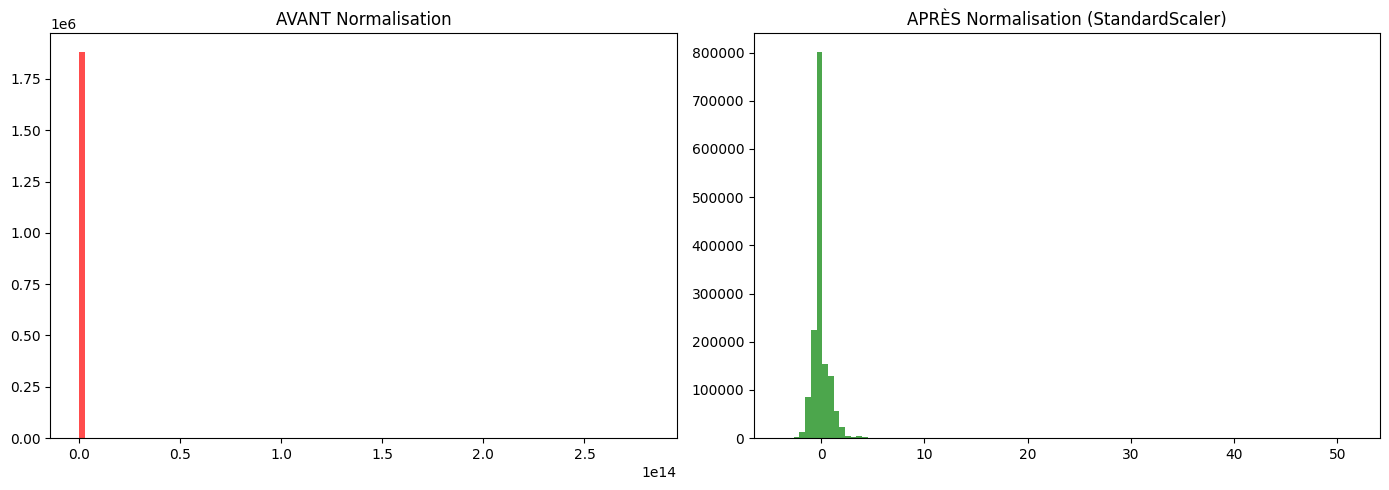

In [22]:
# --- Normalisation : Vérification ---
import matplotlib.pyplot as plt

# Vérification des propriétés
print(f"Train - Moyenne : {X_train.mean():.6f} (~0) ✓")
print(f"Train - Std     : {X_train.std():.6f} (~1) ✓")
print(f"Test  - Moyenne : {X_test.mean():.6f}")
print(f"Test  - Std     : {X_test.std():.6f}")

# Comparaison avant/après normalisation
smart_cols = [c for c in df_all_sequences.columns if 'smart_' in c]
raw_data   = df_all_sequences[smart_cols].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(raw_data.reshape(-1),   bins=100, color='red',   alpha=0.7)
axes[0].set_title('AVANT Normalisation')
axes[1].hist(X_train.reshape(-1),    bins=100, color='green', alpha=0.7)
axes[1].set_title('APRÈS Normalisation (StandardScaler)')
plt.tight_layout()
plt.show()

**Restructuration des données pour le modèle CNN-LSTM**

In [23]:
# --- Restructuration 3D : Vérification ---

print(f"X_train : {X_train.shape} ✓")
print(f"X_test  : {X_test.shape} ✓")
print(f"y_train : {y_train.shape} ✓")
print(f"y_test  : {y_test.shape} ✓")
print(f"input_shape = ({X_train.shape[1]}, {X_train.shape[2]})")

X_train : (2388, 30, 21) ✓
X_test  : (597, 30, 21) ✓
y_train : (2388,) ✓
y_test  : (597,) ✓
input_shape = (30, 21)


**9.1 Alignement des étiquettes avec les séquences**

In [24]:
# --- Partie 9.1 : Alignement des étiquettes ---
import gc

# Vérifications
assert X_train.shape[0] == y_train.shape[0]
assert X_test.shape[0]  == y_test.shape[0]
assert set(np.unique(y_train)) | set(np.unique(y_test)) == {0, 1}

print(f"y_train : 0={(y_train==0).sum()}, 1={(y_train==1).sum()}")
print(f"y_test  : 0={(y_test==0).sum()}, 1={(y_test==1).sum()}")

gc.collect()

y_train : 0=1600, 1=788
y_test  : 0=400, 1=197


33

**Partie 10 : Modèle CNN-LSTM (Complet avec Entraînement)**

In [25]:
# --- Partie 10 : Modèle CNN-LSTM ---
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Paramètres
KERNEL_SIZE  = 3
FILTERS      = 64
LSTM_UNITS_1 = 64
LSTM_UNITS_2 = 32
DROPOUT_RATE = 0.2
L2_REG       = 0.001
EPOCHS       = 50
BATCH_SIZE   = 32

n_timesteps, n_features = X_train.shape[1], X_train.shape[2]

# Construction du modèle
model = Sequential([
    Conv1D(FILTERS, KERNEL_SIZE, activation='relu', padding='same',
           input_shape=(n_timesteps, n_features)),
    Conv1D(FILTERS, KERNEL_SIZE, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),
    Dropout(DROPOUT_RATE),
    LSTM(LSTM_UNITS_1, return_sequences=True,  dropout=DROPOUT_RATE, recurrent_dropout=DROPOUT_RATE),
    LSTM(LSTM_UNITS_2, return_sequences=False, dropout=DROPOUT_RATE, recurrent_dropout=DROPOUT_RATE),
    Dropout(DROPOUT_RATE),
    Dense(16, activation='tanh', kernel_regularizer=l2(L2_REG)),
    Dropout(DROPOUT_RATE),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint('/kaggle/working/best_model.h5', monitor='val_loss', save_best_only=True)
]

# Entraînement
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=callbacks,
    class_weight={0: 1.0, 1: 2.0}
)

2026-05-10 17:24:46.799021: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778433887.047939      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778433887.119464      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778433887.671486      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778433887.671521      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778433887.671525      57 computation_placer.cc:177] computation placer alr

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 30, 64)         │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 30, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 15, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,433 (243.88 KB)

 Trainable params: 62,433 (243.88 KB)

...

60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9755 - loss: 0.1659 - val_accuracy: 0.9728 - val_loss: 0.0993
Epoch 5/50
58/60 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9738 - loss: 0.1411

60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9740 - loss: 0.1412 - val_accuracy: 0.9812 - val_loss: 0.0784
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9798 - loss: 0.1292 - val_accuracy: 0.9707 - val_loss: 0.0986
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9890 - loss: 0.0812 - val_accuracy: 0.9728 - val_loss: 0.1107
Epoch 8/50
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9811 - loss: 0.1212

60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9811 - loss: 0.1214 - val_accuracy: 0.9791 - val_loss: 0.0704
Epoch 9/50
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9827 - loss: 0.1135

60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9828 - loss: 0.1132 - val_accuracy: 0.9895 - val_loss: 0.0574
Epoch 10/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9829 - loss: 0.0875 - val_accuracy: 0.9770 - val_loss: 0.0820
Epoch 11/50
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9820 - loss: 0.0919

60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9821 - loss: 0.0917 - val_accuracy: 0.9916 - val_loss: 0.0393
Epoch 12/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9874 - loss: 0.0738 - val_accuracy: 0.9895 - val_loss: 0.0526
Epoch 13/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9923 - loss: 0.0567 - val_accuracy: 0.9916 - val_loss: 0.0411
Epoch 14/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9912 - loss: 0.0754 - val_accuracy: 0.9895 - val_loss: 0.0463
Epoch 15/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9904 - loss: 0.0722 - val_accuracy: 0.9833 - val_loss: 0.0579
Epoch 16/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9898 - loss: 0.0981 - val_accuracy: 0.9833 - val_loss: 0.0551
Epoch 17/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9936 - loss: 0.0652 - val_accuracy: 0.9854 - val_loss: 0.0579
Epoch 18/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9898 - loss: 0.0572 - val_accuracy: 0.9895 - val_l

**Partie 11 : Entraînement et Analyse des Performances**

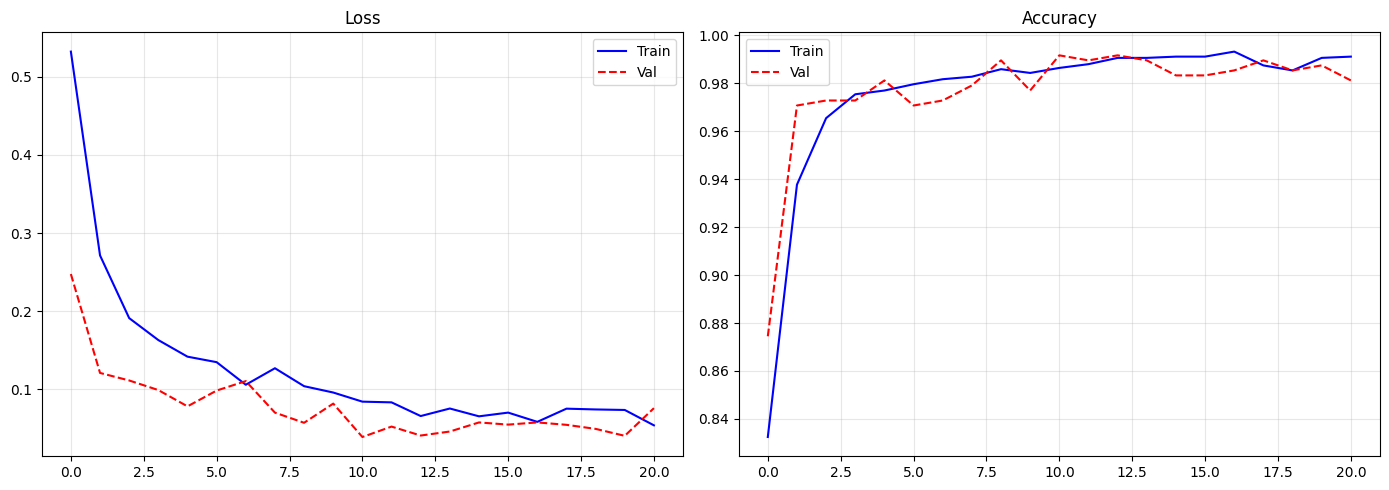

Train Acc : 0.9911 | Val Acc : 0.9812 | Écart : 0.0099
Meilleure époque : 11 | Val Loss min : 0.0393
✅ Bon apprentissage


In [26]:
# --- Partie 11 : Analyse des performances ---
import matplotlib.pyplot as plt

# Courbes d'apprentissage
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train', color='blue')
axes[0].plot(history.history['val_loss'], label='Val',   color='red', linestyle='--')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='Train', color='blue')
axes[1].plot(history.history['val_accuracy'], label='Val',   color='red', linestyle='--')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analyse
train_acc = history.history['accuracy'][-1]
val_acc   = history.history['val_accuracy'][-1]
val_loss  = history.history['val_loss']
ecart     = abs(train_acc - val_acc)

print(f"Train Acc : {train_acc:.4f} | Val Acc : {val_acc:.4f} | Écart : {ecart:.4f}")
print(f"Meilleure époque : {val_loss.index(min(val_loss)) + 1} | Val Loss min : {min(val_loss):.4f}")

if train_acc > 0.9 and ecart > 0.1:
    print("⚠️ Surapprentissage (Overfitting)")
elif train_acc < 0.7 and val_acc < 0.7:
    print("⚠️ Sous-apprentissage (Underfitting)")
else:
    print("✅ Bon apprentissage")

**Partie 12 : Évaluation du modèle et analyse des performances**

Train - Loss: 0.0405 | Acc: 0.9925 | MAE: 0.0075
Test  - Loss: 0.0287  | Acc: 0.9950  | MAE: 0.0050


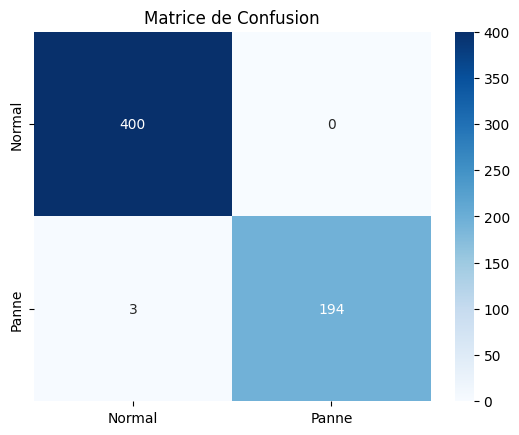


TRAIN :
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99      1600
  Défaillant       1.00      0.98      0.99       788

    accuracy                           0.99      2388
   macro avg       0.99      0.99      0.99      2388
weighted avg       0.99      0.99      0.99      2388

TEST :
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00       400
  Défaillant       1.00      0.98      0.99       197

    accuracy                           0.99       597
   macro avg       1.00      0.99      0.99       597
weighted avg       1.00      0.99      0.99       597

Recall test : 0.9848 (✅ > 90%)


In [27]:
# --- Partie 12 : Évaluation finale ---
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import mean_absolute_error, precision_recall_fscore_support
import seaborn as sns

# Charger le meilleur modèle
model.load_weights('/kaggle/working/best_model.h5')

# Prédictions
train_pred = (model.predict(X_train, verbose=0) > 0.5).astype(int).flatten()
test_pred  = (model.predict(X_test,  verbose=0) > 0.5).astype(int).flatten()

# Métriques
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
test_loss,  test_acc  = model.evaluate(X_test,  y_test,  verbose=0)

print(f"Train - Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | MAE: {mean_absolute_error(y_train, train_pred):.4f}")
print(f"Test  - Loss: {test_loss:.4f}  | Acc: {test_acc:.4f}  | MAE: {mean_absolute_error(y_test,  test_pred):.4f}")

# Matrice de confusion
cm = confusion_matrix(y_test, test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Panne'],
            yticklabels=['Normal', 'Panne'])
plt.title('Matrice de Confusion')
plt.show()

# Rapport de classification
print("\nTRAIN :")
print(classification_report(y_train, train_pred, target_names=['Normal', 'Défaillant']))
print("TEST :")
print(classification_report(y_test, test_pred, target_names=['Normal', 'Défaillant']))

# Recall
_, test_rec, _, _ = precision_recall_fscore_support(y_test, test_pred, average='binary')
print(f"Recall test : {test_rec:.4f} ({'✅ > 90%' if test_rec > 0.9 else '⚠️ À améliorer'})")

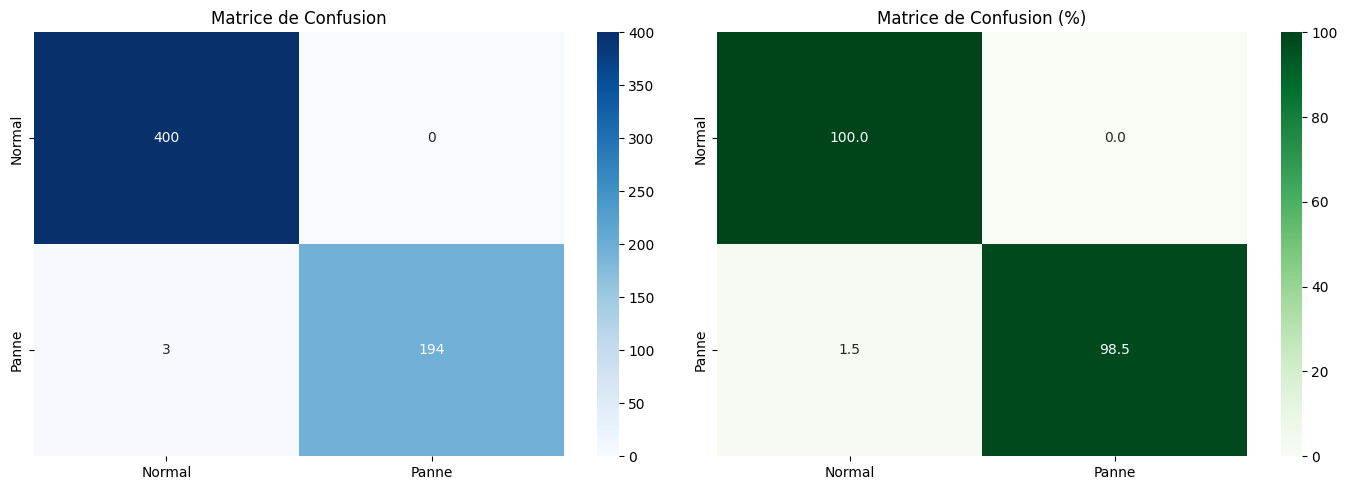

Accuracy  : 0.9950
Precision : 1.0000
Recall    : 0.9848
F1-Score  : 0.9923
MAE       : 0.0050

TP=194, TN=400, FP=0, FN=3
⚠️ Modèle privilégie la PRÉCISION → Risque de rater des pannes


In [28]:
# --- Évaluation avancée : métriques et matrice de confusion ---
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, mean_absolute_error
import seaborn as sns
import matplotlib.pyplot as plt

# Prédictions
y_pred = (model.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
cm     = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Panne'],
            yticklabels=['Normal', 'Panne'], ax=axes[0])
axes[0].set_title('Matrice de Confusion')

cm_norm = cm / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Greens',
            xticklabels=['Normal', 'Panne'],
            yticklabels=['Normal', 'Panne'], ax=axes[1])
axes[1].set_title('Matrice de Confusion (%)')

plt.tight_layout()
plt.show()

# Métriques
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
mae       = mean_absolute_error(y_test, y_pred)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"MAE       : {mae:.4f}")
print(f"\nTP={tp}, TN={tn}, FP={fp}, FN={fn}")

if recall > precision:
    print("✅ Modèle privilégie le RECALL → Bon choix pour maintenance prédictive")
else:
    print("⚠️ Modèle privilégie la PRÉCISION → Risque de rater des pannes")

In [29]:
from tensorflow.keras.layers import Bidirectional, LSTM

print("\n" + "="*70)
print("ENTRAÎNEMENT DU MODÈLE 4 : BiLSTM")
print("="*70)

callbacks_4 = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint('/kaggle/working/best_model_bilstm.keras', monitor='val_loss', save_best_only=True)
]

model_bilstm = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(n_timesteps, n_features)),
    Dropout(0.2),

    Bidirectional(LSTM(32)),
    Dropout(0.2),

    Dense(16, activation='tanh'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_bilstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_bilstm.summary()

history_bilstm = model_bilstm.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks_4,
    class_weight={0: 1.0, 1: 2.0},
    verbose=1
)

model_bilstm.load_weights('/kaggle/working/best_model_bilstm.keras')

train_pred_bilstm = (model_bilstm.predict(X_train, verbose=0) > 0.5).astype(int).flatten()
test_pred_bilstm  = (model_bilstm.predict(X_test, verbose=0) > 0.5).astype(int).flatten()

train_acc_bilstm = accuracy_score(y_train, train_pred_bilstm)
test_acc_bilstm  = accuracy_score(y_test, test_pred_bilstm)
recall_bilstm    = recall_score(y_test, test_pred_bilstm)

print(f"\n📊 BiLSTM - Train Acc: {train_acc_bilstm:.4f} | Test Acc: {test_acc_bilstm:.4f} | Recall: {recall_bilstm:.4f}")


ENTRAÎNEMENT DU MODÈLE 4 : BiLSTM


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 30, 128)        │        44,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,305 (337.13 KB)

 Trainable params: 86,305 (337.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.8225 - loss: 0.5798 - val_accuracy: 0.9582 - val_loss: 0.1335
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9595 - loss: 0.1883 - val_accuracy: 0.9770 - val_loss: 0.0847
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9766 - loss: 0.1323 - val_accuracy: 0.9644 - val_loss: 0.0897
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9755 - loss: 0.1397 - val_accuracy: 0.9812 - val_loss: 0.0832
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9817 - loss: 0.1271 - val_accuracy: 0.9686 - val_loss: 0.0797
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9789 - loss: 0.1071 - val_accuracy: 0.9749 - val_loss: 0.0692
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9828 - loss: 0.0939 - val_accuracy: 0.9833 - val_loss: 0.0612
Epoch 8/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9821 - loss: 0.1008 - val_accuracy: 0.9874 - 

In [30]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, LayerNormalization, MultiHeadAttention, Input, GlobalAveragePooling1D
from tensorflow.keras.models import Model

print("\n" + "="*70)
print("ENTRAÎNEMENT DU MODÈLE 5 : TRANSFORMER")
print("="*70)

# Bloc Transformer
def transformer_block(inputs, head_size=64, num_heads=4, ff_dim=128, dropout=0.2):

    x = LayerNormalization(epsilon=1e-6)(inputs)

    x = MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(x, x)

    x = Dropout(dropout)(x)
    res = x + inputs

    x = LayerNormalization(epsilon=1e-6)(res)

    x = Dense(ff_dim, activation="relu")(x)
    x = Dropout(dropout)(x)
    x = Dense(inputs.shape[-1])(x)

    return x + res


inputs = Input(shape=(n_timesteps, n_features))

x = transformer_block(inputs)
x = transformer_block(x)

x = GlobalAveragePooling1D()(x)
x = Dropout(0.2)(x)

x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)

outputs = Dense(1, activation='sigmoid')(x)

model_transformer = Model(inputs, outputs)

model_transformer.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_transformer.summary()

callbacks_5 = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint('/kaggle/working/best_model_transformer.keras', monitor='val_loss', save_best_only=True)
]

history_transformer = model_transformer.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks_5,
    class_weight={0: 1.0, 1: 2.0},
    verbose=1
)

train_pred_transformer = (model_transformer.predict(X_train, verbose=0) > 0.5).astype(int).flatten()
test_pred_transformer  = (model_transformer.predict(X_test, verbose=0) > 0.5).astype(int).flatten()

train_acc_transformer = accuracy_score(y_train, train_pred_transformer)
test_acc_transformer  = accuracy_score(y_test, test_pred_transformer)
recall_transformer    = recall_score(y_test, test_pred_transformer)

print(f"\n📊 Transformer - Train Acc: {train_acc_transformer:.4f} | Test Acc: {test_acc_transformer:.4f} | Recall: {recall_transformer:.4f}")


ENTRAÎNEMENT DU MODÈLE 5 : TRANSFORMER


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 30, 21)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 21)    │         42 │ input_layer_2[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 21)    │     22,293 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 30, 21)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 21)    │          0 │ dropout_7[0][0],  │
│                     │                   │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 21)    │         42 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 30, 128)   │      2,816 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 30, 128)   │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 30, 21)    │      2,709 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 30, 21)    │          0 │ dense_5[0][0],    │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 21)    │         42 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 21)    │     22,293 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 30, 21)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 30, 21)    │          0 │ dropout_10[0][0], │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 21)    │         42 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 30, 128)   │      2,816 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 30, 128)   │          0 │ dense_6[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 30, 21)    │      2,709 │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 30, 21)    │          0 │ dense_7[0][0],  

 Total params: 57,277 (223.74 KB)

 Trainable params: 57,277 (223.74 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.7868 - loss: 0.5764 - val_accuracy: 0.9477 - val_loss: 0.1421
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.9376 - loss: 0.2328 - val_accuracy: 0.9686 - val_loss: 0.0926
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9670 - loss: 0.1663 - val_accuracy: 0.9686 - val_loss: 0.0818
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9681 - loss: 0.1521 - val_accuracy: 0.9665 - val_loss: 0.1015
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9764 - loss: 0.1162 - val_accuracy: 0.9686 - val_loss: 0.0973
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.9731 - loss: 0.1201 - val_accuracy: 0.9770 - val_loss: 0.0558
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.9658 - loss: 0.1294 - val_accuracy: 0.9854 - val_loss: 0.0540
Epoch 8/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9727 - loss: 0.1126 - val_accuracy: 0.9770 - 

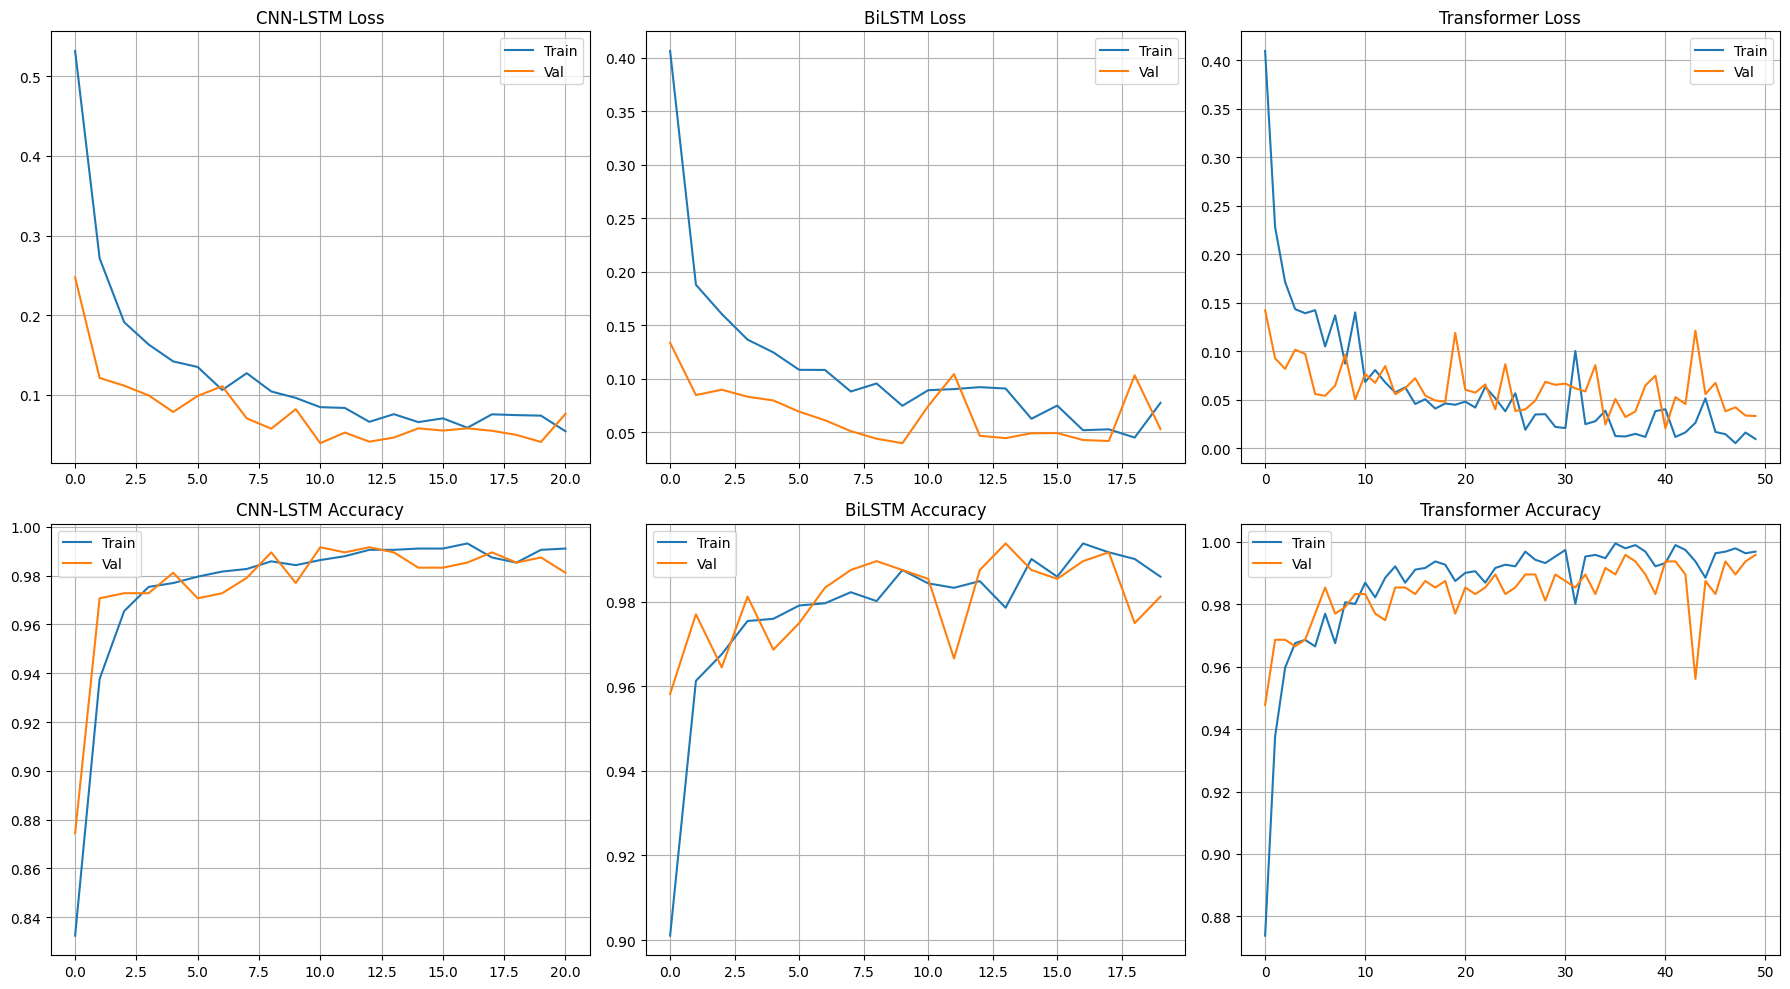

In [31]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ================= CNN-LSTM =================
axes[0,0].plot(history.history['loss'], label='Train')
axes[0,0].plot(history.history['val_loss'], label='Val')
axes[0,0].set_title("CNN-LSTM Loss")
axes[0,0].legend()
axes[0,0].grid()

axes[1,0].plot(history.history['accuracy'], label='Train')
axes[1,0].plot(history.history['val_accuracy'], label='Val')
axes[1,0].set_title("CNN-LSTM Accuracy")
axes[1,0].legend()
axes[1,0].grid()

# ================= BiLSTM =================
axes[0,1].plot(history_bilstm.history['loss'], label='Train')
axes[0,1].plot(history_bilstm.history['val_loss'], label='Val')
axes[0,1].set_title("BiLSTM Loss")
axes[0,1].legend()
axes[0,1].grid()

axes[1,1].plot(history_bilstm.history['accuracy'], label='Train')
axes[1,1].plot(history_bilstm.history['val_accuracy'], label='Val')
axes[1,1].set_title("BiLSTM Accuracy")
axes[1,1].legend()
axes[1,1].grid()

# ================= Transformer =================
axes[0,2].plot(history_transformer.history['loss'], label='Train')
axes[0,2].plot(history_transformer.history['val_loss'], label='Val')
axes[0,2].set_title("Transformer Loss")
axes[0,2].legend()
axes[0,2].grid()

axes[1,2].plot(history_transformer.history['accuracy'], label='Train')
axes[1,2].plot(history_transformer.history['val_accuracy'], label='Val')
axes[1,2].set_title("Transformer Accuracy")
axes[1,2].legend()
axes[1,2].grid()

plt.tight_layout()
plt.show()

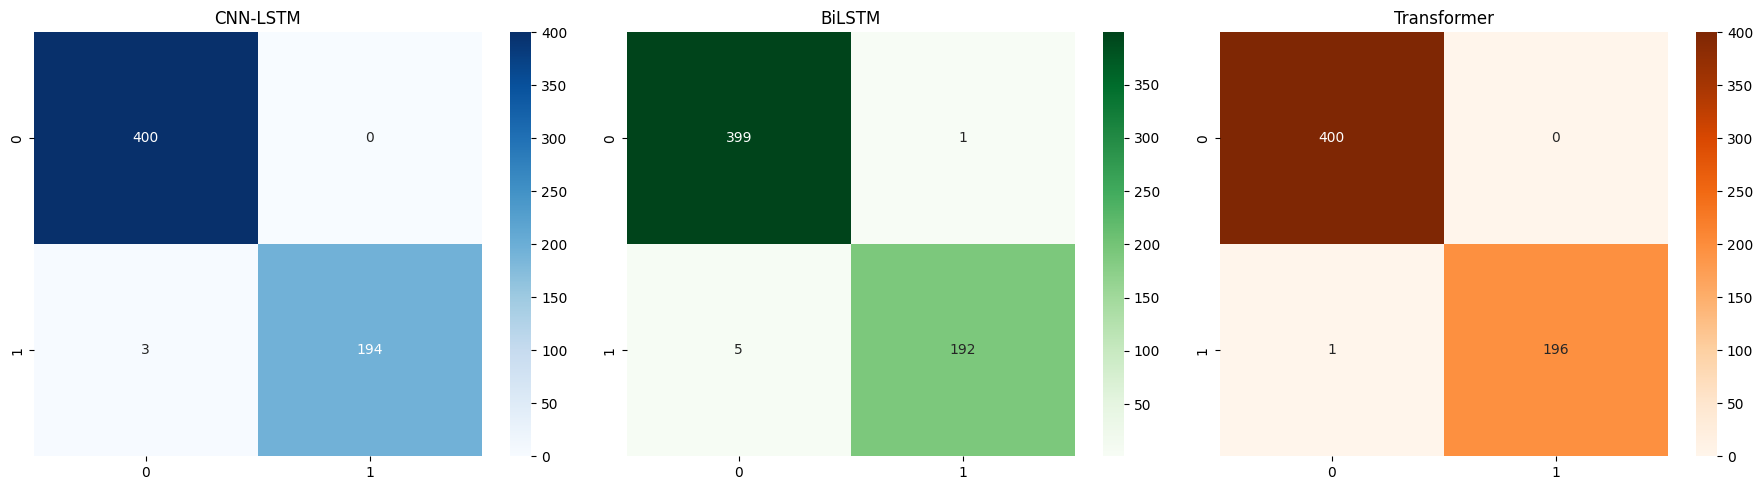

In [32]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ================= CNN-LSTM =================
cm1 = confusion_matrix(y_test, test_pred)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("CNN-LSTM")

# ================= BiLSTM =================
cm2 = confusion_matrix(y_test, test_pred_bilstm)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("BiLSTM")

# ================= Transformer =================
cm3 = confusion_matrix(y_test, test_pred_transformer)
sns.heatmap(cm3, annot=True, fmt='d', cmap='Oranges', ax=axes[2])
axes[2].set_title("Transformer")

plt.tight_layout()
plt.show()

In [33]:
from sklearn.metrics import accuracy_score, recall_score
import pandas as pd

comparison = pd.DataFrame({
    "Modèle": ["CNN-LSTM", "BiLSTM", "Transformer"],

    "Accuracy Test": [
        accuracy_score(y_test, test_pred),
        accuracy_score(y_test, test_pred_bilstm),
        accuracy_score(y_test, test_pred_transformer)
    ],

    "Recall (Panne)": [
        recall_score(y_test, test_pred),
        recall_score(y_test, test_pred_bilstm),
        recall_score(y_test, test_pred_transformer)
    ]
})

print(comparison)

        Modèle  Accuracy Test  Recall (Panne)
0     CNN-LSTM       0.994975        0.984772
1       BiLSTM       0.989950        0.974619
2  Transformer       0.998325        0.994924
